In [13]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score

import knižnic

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
DATA_DIR = 'C:/Users/Кирка/PycharmProjects/pythonProjectТNN/train'

Constants

In [4]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.load_data()

    def load_data(self):
        for label in os.listdir(self.data_dir):
            label_path = os.path.join(self.data_dir, label)
            if not os.path.isdir(label_path):
                continue
            for file in os.listdir(label_path):
                if file == '.DS_Store':
                    continue
                file_path = os.path.join(label_path, file)
                img = Image.open(file_path).convert('L')
                if self.transform:
                    img = self.transform(img)
                self.images.append(img)
                self.labels.append(int(label))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        return img, label

trieda CustomDataset je vlastný súbor údajov na načítanie obrázkov a ich zodpovedajúcich označení.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transforms.ToTensor() je transformácia, ktorá konvertuje obrázok na tenzor PyTorch. Tenzory v PyTorch sa používajú na reprezentáciu údajov a operácií v neurónových sieťach.

transformuje.Normalizovať((0.5,), (0.5,)) je normalizácia obrázka. Normalizácia vstupných obrazových dát je dôležitá pre efektívne trénovanie modelu. Táto transformácia sústreďuje údaje okolo priemeru a normalizuje ho štandardnou odchýlkou. Tu parametre (0,5,) a (0,5,) označujú priemer a štandardnú odchýlku pre každý kanál obrázka (v tomto prípade, keďže obrázky sú prevedené do odtieňov šedej, máme len jeden kanál).

In [6]:
dataset = CustomDataset(DATA_DIR, transform=transform)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Pripravujeme dáta pre tréning, validáciu a testovanie modelu strojového učenia.

In [7]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.flatten = nn.Flatten() #преобразует входные данные в одномерный вектор.
        self.fc1 = nn.Linear(28 * 28, 128) #полносвязный слой с 28*28 входами и 128 выходами.
        self.dropout1 = nn.Dropout(0.5)  # Добавляем dropout с вероятностью отключения 0.5
        self.fc2 = nn.Linear(128, 64) # полносвязный слой с 128 входами и 64 выходами.
        self.dropout2 = nn.Dropout(0.5)  # Добавляем dropout с вероятностью отключения 0.5
        self.fc3 = nn.Linear(64, len(np.unique(dataset.labels))) #полносвязный слой с 64 входами и количеством выходов, равным количеству уникальных меток в датасете.

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)  # Применяем dropout после первого полносвязного слоя
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)  # Применяем dropout после второго полносвязного слоя
        x = self.fc3(x)
        return x


model = Net().to(device) #model na device
optimizer = optim.Adam(model.parameters(), lr=0.001)#Optimalizátor Adam sa používa na aktualizáciu modelových váh počas tréningového procesu. lr=0,001 - rýchlosť učenia.
criterion = nn.CrossEntropyLoss()#chybový priestor

Definujeme architektúru neurónovej siete, vytvoríme inštanciu modelu, definujeme optimalizátor a stratovú funkciu pre tréning.

Этот блок кода отвечает за обучение и валидацию модели на протяжении заданного числа эпох

In [8]:
num_epochs = 20
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad() #Resetovanie prechodov optimalizátora na nulu
        outputs = model(imgs)#Prenos údajov cez model
        loss = criterion(outputs, labels)#Vypočítame stratovú funkciu medzi predpoveďami a skutočnými označeniami
        loss.backward()#Vykonávame spätné šírenie chýb
        optimizer.step()#Parametre modelu aktualizujeme pomocou optimalizátora
        #Spočítame straty a vypočítame presnosť predpovedí.
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    model.eval()#uveďte model do hodnotiaceho režimu
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")


Epoch 1/20, Train Loss: 0.4275, Train Accuracy: 87.14%, Val Loss: 0.2921, Val Accuracy: 91.51%
Epoch 2/20, Train Loss: 0.2103, Train Accuracy: 93.63%, Val Loss: 0.2276, Val Accuracy: 93.02%
Epoch 3/20, Train Loss: 0.1600, Train Accuracy: 95.04%, Val Loss: 0.1884, Val Accuracy: 94.22%
Epoch 4/20, Train Loss: 0.1284, Train Accuracy: 95.95%, Val Loss: 0.1839, Val Accuracy: 94.13%
Epoch 5/20, Train Loss: 0.1140, Train Accuracy: 96.48%, Val Loss: 0.1313, Val Accuracy: 96.13%
Epoch 6/20, Train Loss: 0.1009, Train Accuracy: 96.78%, Val Loss: 0.1433, Val Accuracy: 95.70%
Epoch 7/20, Train Loss: 0.0873, Train Accuracy: 97.21%, Val Loss: 0.1428, Val Accuracy: 95.88%
Epoch 8/20, Train Loss: 0.0811, Train Accuracy: 97.36%, Val Loss: 0.1278, Val Accuracy: 96.06%
Epoch 9/20, Train Loss: 0.0716, Train Accuracy: 97.67%, Val Loss: 0.1378, Val Accuracy: 96.07%
Epoch 10/20, Train Loss: 0.0688, Train Accuracy: 97.73%, Val Loss: 0.1296, Val Accuracy: 96.24%
Epoch 11/20, Train Loss: 0.0632, Train Accuracy: 

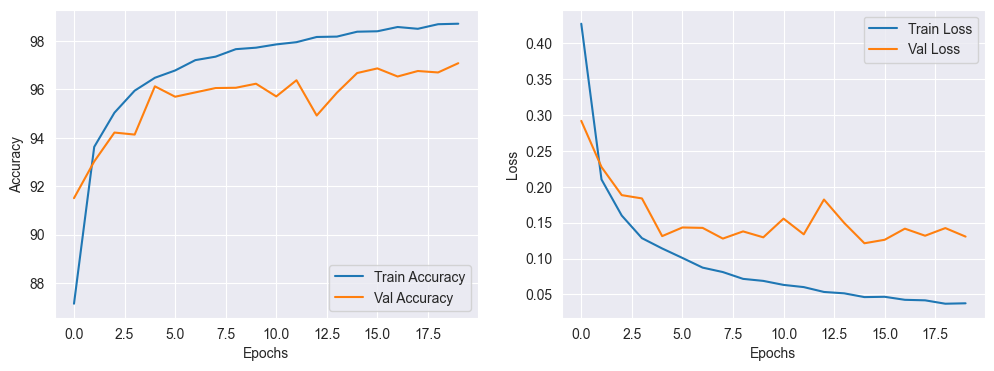

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())


Tento blok kódu je určený na testovanie modelu na testovacom súbore údajov.

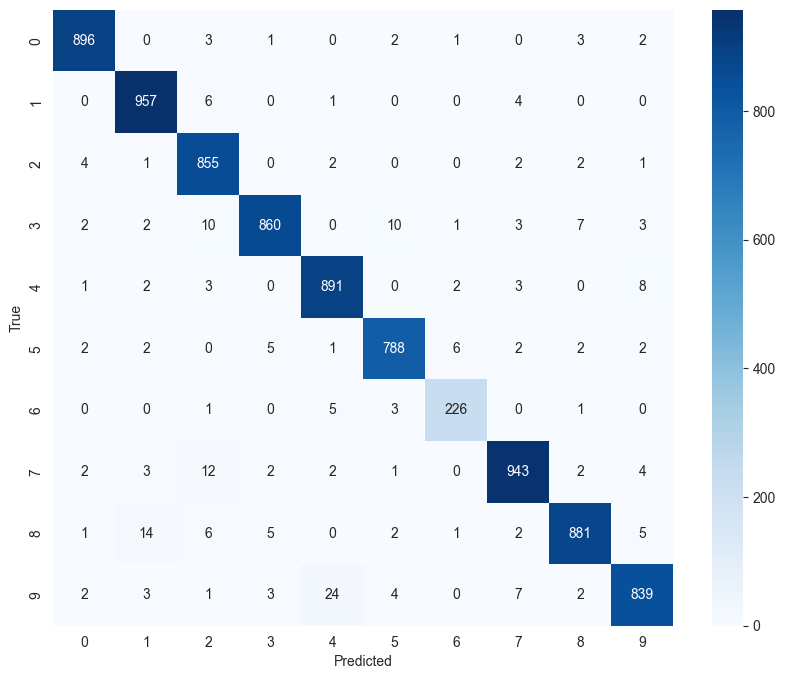

In [11]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [14]:
report = classification_report(y_true, y_pred, target_names=[str(i) for i in range(len(np.unique(dataset.labels)))])
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(report)

Accuracy: 0.9720
Precision: 0.9707
Recall: 0.9709
F1 Score: 0.9707
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       908
           1       0.97      0.99      0.98       968
           2       0.95      0.99      0.97       867
           3       0.98      0.96      0.97       898
           4       0.96      0.98      0.97       910
           5       0.97      0.97      0.97       810
           6       0.95      0.96      0.96       236
           7       0.98      0.97      0.97       971
           8       0.98      0.96      0.97       917
           9       0.97      0.95      0.96       885

    accuracy                           0.97      8370
   macro avg       0.97      0.97      0.97      8370
weighted avg       0.97      0.97      0.97      8370

